# Разведочный анализ данных

## Цель работы
Провести разведочный анализ данных по визитам сайта и исследовать факторы, которые могут быть связаны с целевым действием.

## Важно
В данной работе признаки из ga_hits.csv, агрегированные по всей сессии, не используются для обучения модели, так как они приводят к утечке данных.  
Файл ga_hits.csv используется только для формирования целевой переменной has_target.

## План
1. Загрузить данные.
2. Объединить ga_sessions.csv с честной целевой переменной.
3. Исследовать пропуски, типы данных и баланс классов.
4. Исследовать конверсию по источникам, устройствам, географии и времени.
5. Выполнить корреляционный анализ числовых признаков.
6. Сделать выводы для дальнейшего моделирования.

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

Загрузка данных

In [2]:
ga_sessions = pd.read_csv("ga_sessions.csv", low_memory=False)
session_target = pd.read_csv("session_target.csv")

print("ga_sessions:", ga_sessions.shape)
print("session_target:", session_target.shape)

display(ga_sessions.head())
display(session_target.head())

ga_sessions: (1860042, 18)
session_target: (1734610, 2)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


,session_id,has_target
0,1000043953525145011.1638186424.1638186424,0
1,1000070419113613119.1638176575.1638176575,0
2,1000070874380665204.1638695315.1638695315,0
3,1000086147286198824.1640524329.1640524329,0
4,1000101955269479.1640526697.1640526697,0


Объединение таблиц

In [3]:
df = ga_sessions.merge(session_target, on="session_id", how="left")
df["has_target"] = df["has_target"].fillna(0).astype(int)

print("Размер объединённой таблицы:", df.shape)
display(df.head())

Размер объединённой таблицы: (1860042, 19)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,has_target
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow,0


In [4]:
print("Размер таблицы:", df.shape)
print("Количество дубликатов строк:", df.duplicated().sum())
print("Количество дубликатов session_id:", df["session_id"].duplicated().sum())

print("\nТипы данных:")
display(df.dtypes)

print("\nПропуски по столбцам:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

Размер таблицы: (1860042, 19)
Количество дубликатов строк: 0
Количество дубликатов session_id: 0

Типы данных:


session_id                    str
client_id                     str
visit_date                    str
visit_time                    str
visit_number                int64
utm_source                    str
utm_medium                    str
utm_campaign                  str
utm_adcontent                 str
utm_keyword                   str
device_category               str
device_os                     str
device_brand                  str
device_model                  str
device_screen_resolution      str
device_browser                str
geo_country                   str
geo_city                      str
has_target                  int64
dtype: object


Пропуски по столбцам:


device_model     1843704
utm_keyword      1082061
device_os        1070138
device_brand      367178
utm_adcontent     335615
utm_campaign      219603
utm_source            97
dtype: int64

## Первичная проверка данных

На этом этапе оценивается базовое качество датасета:
- размер таблицы;
- наличие дубликатов;
- типы данных;
- пропуски по признакам.

Это важно для того, чтобы до начала моделирования понять, требуется ли очистка данных и какие столбцы могут создать проблемы при обучении модели.

Общая информация

In [5]:
print("Типы данных:")
display(df.dtypes.value_counts())

Типы данных:


str      17
int64     2
Name: count, dtype: int64

In [6]:
# Простейшая типизация времени и дат
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["visit_time"] = df["visit_time"].astype(str)

print("После типизации:")
display(df[["visit_date", "visit_time"]].dtypes)

После типизации:


visit_date    datetime64[us]
visit_time               str
dtype: object

## Типизация данных

Для дальнейшего анализа важно привести дату и время к удобному виду.
Это нужно для построения временных признаков и корректного хронологического разбиения train/test.

## Первичный вывод

На этом этапе изучается структура данных, типы признаков и пропуски.  
Это нужно для того, чтобы понять, какие признаки можно использовать в модели и какая предобработка потребуется дальше.

Баланс классов

Распределение целевой переменной:


has_target
0    1809728
1      50314
Name: count, dtype: int64

has_target
0    0.97295
1    0.02705
Name: proportion, dtype: float64

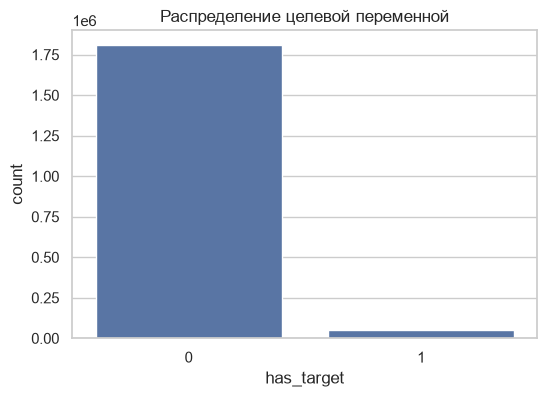

In [7]:
print("Распределение целевой переменной:")
display(df["has_target"].value_counts())
display(df["has_target"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x="has_target", data=df)
plt.title("Распределение целевой переменной")
plt.show()

Преобразование времени

In [8]:
df["visit_datetime"] = pd.to_datetime(
    df["visit_date"].astype(str) + " " + df["visit_time"].astype(str),
    errors="coerce"
)

df["visit_hour"] = df["visit_datetime"].dt.hour
df["visit_dayofweek"] = df["visit_datetime"].dt.dayofweek
df["visit_month"] = df["visit_datetime"].dt.month
df["is_weekend"] = df["visit_dayofweek"].isin([5, 6]).astype(int)

display(df[["visit_date", "visit_time", "visit_datetime", "visit_hour", "visit_dayofweek", "is_weekend"]].head())

,visit_date,visit_time,visit_datetime,visit_hour,visit_dayofweek,is_weekend
0,2021-11-24,14:36:32,2021-11-24 14:36:32,14,2,0
1,2021-11-14,08:21:30,2021-11-14 08:21:30,8,6,1
2,2021-12-28,02:42:06,2021-12-28 02:42:06,2,1,0
3,2021-05-29,05:00:00,2021-05-29 05:00:00,5,5,1
4,2021-05-29,05:00:00,2021-05-29 05:00:00,5,5,1


In [10]:
# Дополнительные простые инженерные признаки
df["is_organic"] = df["utm_medium"].isin(["organic", "referral", "(none)"]).astype(int)
df["is_paid"] = (~df["utm_medium"].isin(["organic", "referral", "(none)"])).astype(int)
df["is_first_visit"] = (df["visit_number"] == 1).astype(int)

social_sources = [
    "QxAxdyPLuQMEcrdZWdWb",
    "MvfHsxITijuriZxsqZqt",
    "ISrKoXQCxqqYvAZICvjs",
    "IZEXUFLARCUMynmHNBGo",
    "PlbkrSYoHuZBWfYjYnfw"
]

df["is_social"] = df["utm_source"].isin(social_sources).astype(int)

display(
    df[[
        "visit_number",
        "visit_hour",
        "visit_dayofweek",
        "visit_month",
        "is_weekend",
        "is_organic",
        "is_paid",
        "is_first_visit",
        "is_social"
    ]].head()
)

,visit_number,visit_hour,visit_dayofweek,visit_month,is_weekend,is_organic,is_paid,is_first_visit,is_social
0,1,14,2,11,0,0,1,1,0
1,1,8,6,11,1,0,1,1,1
2,1,2,1,12,0,0,1,1,0
3,1,5,5,5,1,0,1,1,0
4,2,5,5,5,1,0,1,0,0


## Базовый feature engineering для EDA

На этом этапе создаются простые интерпретируемые признаки:
- органический / платный трафик;
- первый визит;
- выходной день;
- признак трафика из соцсетей.

Такие признаки полезны не только для модели, но и для анализа конверсии по понятным бизнес-группам.

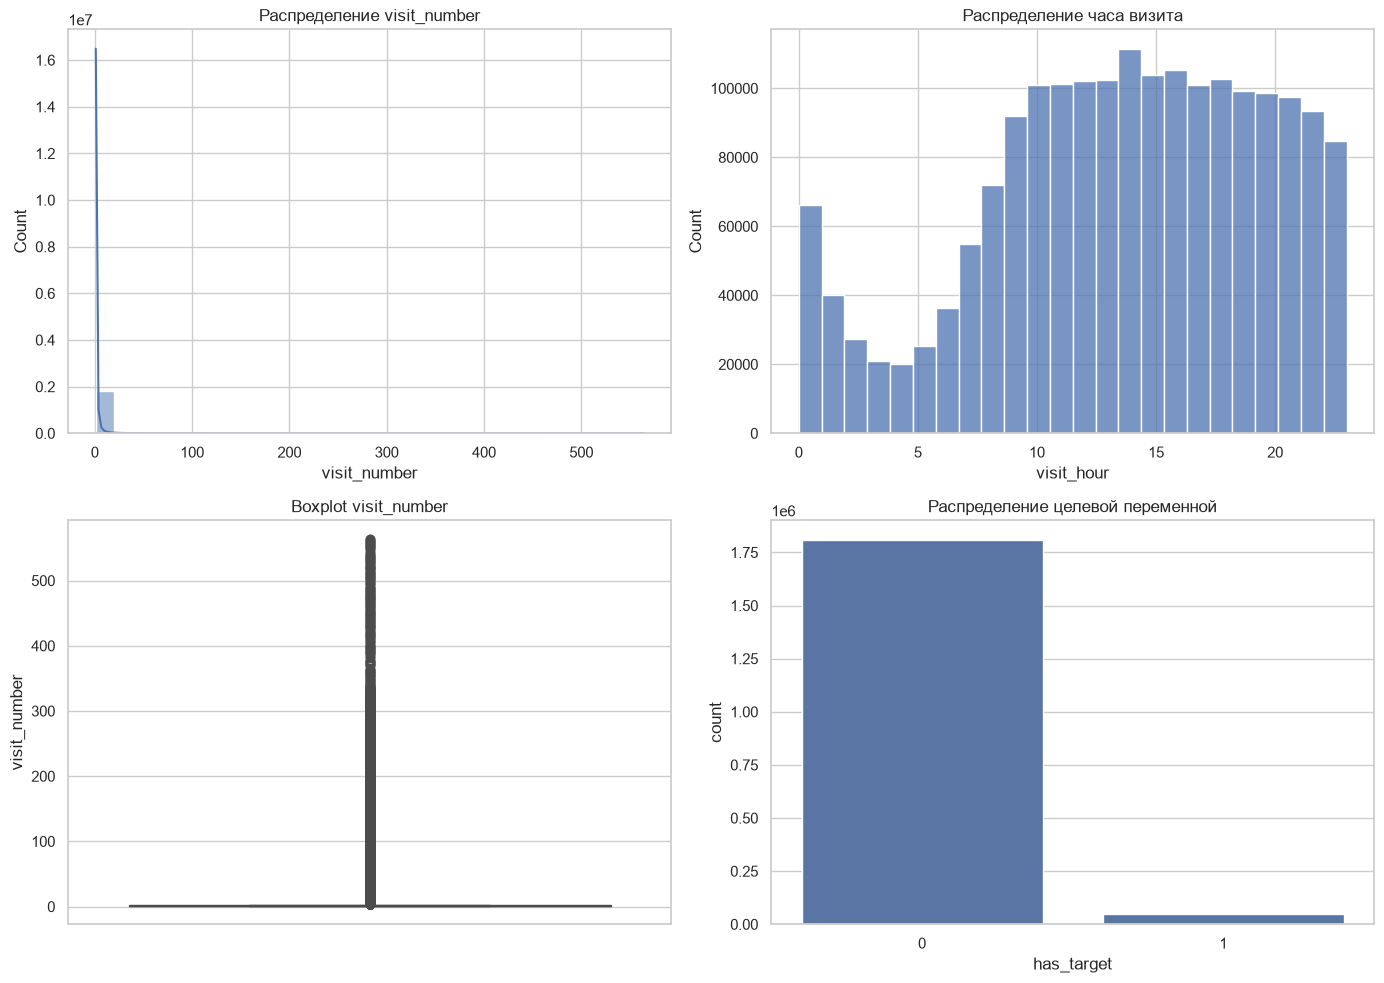

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["visit_number"].dropna(), bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение visit_number")

sns.histplot(df["visit_hour"].dropna(), bins=24, kde=False, ax=axes[0, 1])
axes[0, 1].set_title("Распределение часа визита")

sns.boxplot(y=df["visit_number"], ax=axes[1, 0])
axes[1, 0].set_title("Boxplot visit_number")

sns.countplot(x="has_target", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Распределение целевой переменной")

plt.tight_layout()
plt.show()

## Краткий вывод по распределениям

По графикам видно, что распределение visit_number имеет правостороннюю асимметрию, а у части признаков наблюдаются выбросы.  
Также видно, что целевая переменная несбалансирована, поэтому при оценке модели недостаточно ориентироваться только на accuracy.

## Распределения ключевых признаков

На этом этапе анализируются распределения ключевых признаков и целевой переменной.
Это позволяет понять:
- есть ли сильная асимметрия;
- есть ли выбросы;
- насколько сбалансирован target;
- требуется ли дополнительная обработка признаков перед моделированием.

Конверсия по бизнес-понятным группам

In [12]:
for col in ["is_organic", "is_paid", "is_first_visit", "is_social", "is_weekend"]:
    conv = df.groupby(col)["has_target"].mean()
    print(f"\nКонверсия по {col}:")
    display(conv)


Конверсия по is_organic:


is_organic
0    0.021945
1    0.040360
Name: has_target, dtype: float64


Конверсия по is_paid:


is_paid
0    0.040360
1    0.021945
Name: has_target, dtype: float64


Конверсия по is_first_visit:


is_first_visit
0    0.037106
1    0.023516
Name: has_target, dtype: float64


Конверсия по is_social:


is_social
0    0.029191
1    0.014518
Name: has_target, dtype: float64


Конверсия по is_weekend:


is_weekend
0    0.027847
1    0.024567
Name: has_target, dtype: float64

## Конверсия по укрупнённым группам

Дополнительно полезно оценить конверсию не только по исходным полям, но и по более интерпретируемым группам:
- органический / платный трафик;
- первый визит;
- трафик из соцсетей;
- будни / выходные.

Это помогает увидеть более общие закономерности поведения пользователей.

Heatmap корреляций

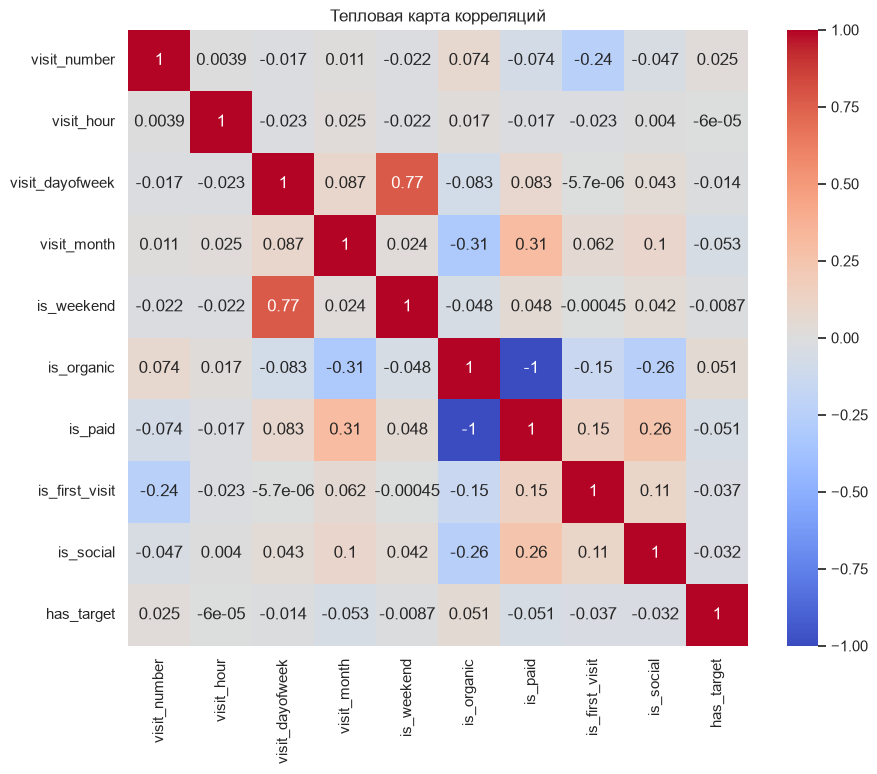

In [13]:
numeric_cols = [
    "visit_number",
    "visit_hour",
    "visit_dayofweek",
    "visit_month",
    "is_weekend",
    "is_organic",
    "is_paid",
    "is_first_visit",
    "is_social",
    "has_target",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Тепловая карта корреляций")
plt.show()

## Краткий вывод по корреляциям

Линейная связь отдельных числовых признаков с целевой переменной выглядит ограниченной.  
Это означает, что для прогноза вероятности целевого действия могут лучше подойти нелинейные модели, чем только простые линейные подходы.

## Корреляционный анализ

Тепловая карта корреляций позволяет понять, какие числовые признаки сильнее связаны с целевой переменной и между собой.
Если линейная связь с has_target слабая, это означает, что для качественного прогноза могут понадобиться более гибкие нелинейные модели.

Конверсия по источникам трафика

In [14]:
for col in ["utm_source", "utm_medium", "utm_campaign"]:
    if col in df.columns:
        conv = df.groupby(col)["has_target"].mean().sort_values(ascending=False).head(15)
        print(f"\nКонверсия по {col}:")
        display(conv)


Конверсия по utm_source:


utm_source
YpBKcihLLfFjWuxOLfvW    1.000000
fJCYsujgSxIHFbOmgDdN    0.875000
XzfzEBYZWgSDtJNXOadn    0.500000
CqeIpFwJscTsZoYXdHsP    0.500000
yxJKymlSGVuKIPTxbysx    0.333333
LIWKeifdTCbuNeniIUqm    0.298246
JcVHXwVSrnfIuOMMEkrJ    0.250000
hIlpdXTVGwzYWIOqvhtN    0.200000
hONgZhBaHwLGhvJSefNE    0.200000
rGDSdilqpnHoxSsEYvjb    0.166667
SbQJoCCWibshtEmQeuVM    0.166667
juYouSPHPfKdXivEPJjt    0.166667
PKriXrefSFPLBYtCRGSE    0.153846
gLXXuZYbFVYlDWhMmZiU    0.125000
LkGnzVRewoaOHnMCwadT    0.125000
Name: has_target, dtype: float64


Конверсия по utm_medium:


utm_medium
dom_click    1.000000
link         0.298246
landing      0.141791
medium       0.125000
social       0.111111
CPM          0.075000
sms          0.066946
(not set)    0.058333
referral     0.053805
static       0.045455
clicks       0.044968
smm          0.043829
(none)       0.035036
organic      0.033315
cpa          0.030615
Name: has_target, dtype: float64


Конверсия по utm_campaign:


utm_campaign
JkhCpeDGCtTwhwqWLywv    1.000000
MHdHrBKQwbDaRalwnlJq    1.000000
IRKNegNgOUQLwudzMElF    0.875000
SbYAsCvXapXBOIxEKBZs    0.500000
lndNIerCYECRQvBTyTye    0.273810
KAcUKGokhYlMktQhYKHx    0.250000
vZqcBrFwxYPoYzJyhYGI    0.222222
TOSjvKcurFlcKJijjpYP    0.200000
DlOlXJaBJgWQVhgtCeWo    0.166667
emlBaVkgLVRqbEVOSSXt    0.150571
KCcrgoFqYxCpSjdRyJjZ    0.140741
ZdOcFAQpRQWuFZHHkEJQ    0.130435
tlfQioxYValDMNqdTGFZ    0.128205
bSnjzIuKqgqYvqVDKaOX    0.111111
CqFuKxSYgtGbcafqJwij    0.111111
Name: has_target, dtype: float64

## Краткий вывод по источникам трафика

По таблице видно, что конверсия различается в зависимости от источника трафика.  
Это означает, что характеристики привлечения пользователя действительно связаны с вероятностью целевого действия и могут быть полезны для модели.

Конверсия по устройствам

In [15]:
for col in ["device_category", "device_os", "device_browser"]:
    if col in df.columns:
        conv = df.groupby(col)["has_target"].mean().sort_values(ascending=False).head(15)
        print(f"\nКонверсия по {col}:")
        display(conv)


Конверсия по device_category:


device_category
desktop    0.031382
mobile     0.026022
tablet     0.023050
Name: has_target, dtype: float64


Конверсия по device_os:


device_os
Macintosh        0.031099
Android          0.020392
iOS              0.018923
Windows          0.018492
Linux            0.017578
(not set)        0.000000
BlackBerry       0.000000
Chrome OS        0.000000
Firefox OS       0.000000
Nokia            0.000000
Samsung          0.000000
Tizen            0.000000
Windows Phone    0.000000
Name: has_target, dtype: float64


Конверсия по device_browser:


device_browser
com.vk.vkclient     0.250000
Firefox             0.034844
Edge                0.032742
Maxthon             0.032258
YaBrowser           0.030650
Android Webview     0.028084
Safari              0.027840
Chrome              0.026828
Samsung Internet    0.026570
Puffin              0.022222
Opera               0.020920
Safari (in-app)     0.017465
UC Browser          0.016073
MRCHROME            0.012987
Nokia501            0.000000
Name: has_target, dtype: float64

## Краткий вывод по устройствам

Конверсия зависит от типа устройства и браузера, что может отражать различия в пользовательском поведении и удобстве взаимодействия с сайтом.

Конверсия по географии

In [16]:
for col in ["geo_country", "geo_city"]:
    if col in df.columns:
        conv = df.groupby(col)["has_target"].mean().sort_values(ascending=False).head(15)
        print(f"\nКонверсия по {col}:")
        display(conv)


Конверсия по geo_country:


geo_country
Morocco         0.139303
Albania         0.121212
Slovenia        0.108696
Philippines     0.074074
Serbia          0.063636
Pakistan        0.062500
Afghanistan     0.060606
South Africa    0.058824
Estonia         0.054348
Iraq            0.054348
Turkmenistan    0.050847
Argentina       0.050000
Cuba            0.046154
Bulgaria        0.044776
Croatia         0.042945
Name: has_target, dtype: float64


Конверсия по geo_city:


geo_city
Rostock          1.000000
Laguna Niguel    1.000000
Nipomo           1.000000
Senftenberg      1.000000
Gravesend        1.000000
Middletown       1.000000
Royan            1.000000
Nybro            1.000000
Guingamp         1.000000
Beaver Falls     1.000000
Qingdao          1.000000
Brescia          1.000000
Seminole         0.833333
Merced           0.666667
Yeovil           0.500000
Name: has_target, dtype: float64

## Краткий вывод по географии

Конверсия различается по странам и городам, что может отражать различия в составе аудитории, интересе к продукту и локальных особенностях поведения пользователей.

Конверсия по времени

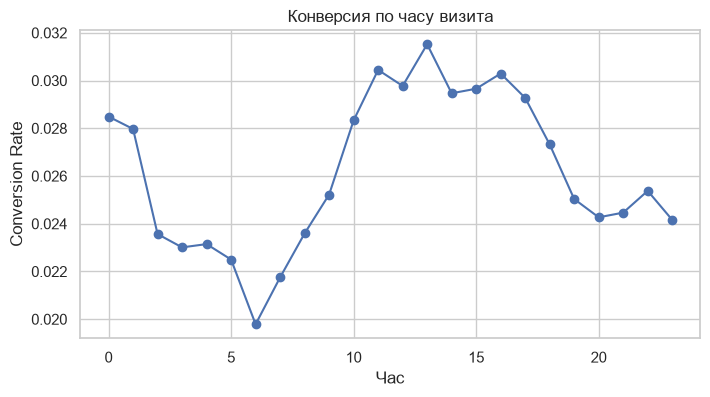

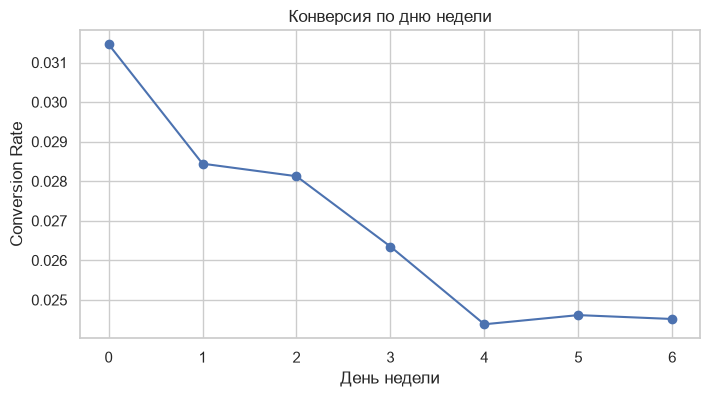

In [17]:
hour_conv = df.groupby("visit_hour")["has_target"].mean()
dow_conv = df.groupby("visit_dayofweek")["has_target"].mean()

plt.figure(figsize=(8, 4))
hour_conv.plot(marker="o")
plt.title("Конверсия по часу визита")
plt.xlabel("Час")
plt.ylabel("Conversion Rate")
plt.show()

plt.figure(figsize=(8, 4))
dow_conv.plot(marker="o")
plt.title("Конверсия по дню недели")
plt.xlabel("День недели")
plt.ylabel("Conversion Rate")
plt.show()

## Краткий вывод по времени визита

Конверсия меняется в зависимости от часа визита и дня недели.  
Следовательно, временные признаки имеют смысл включать в модель.

Анализ числовых признаков

In [18]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Числовые признаки:")
print(numeric_cols)

Числовые признаки:
['visit_number', 'has_target', 'is_weekend', 'is_organic', 'is_paid', 'is_first_visit', 'is_social']


Корреляционный анализ

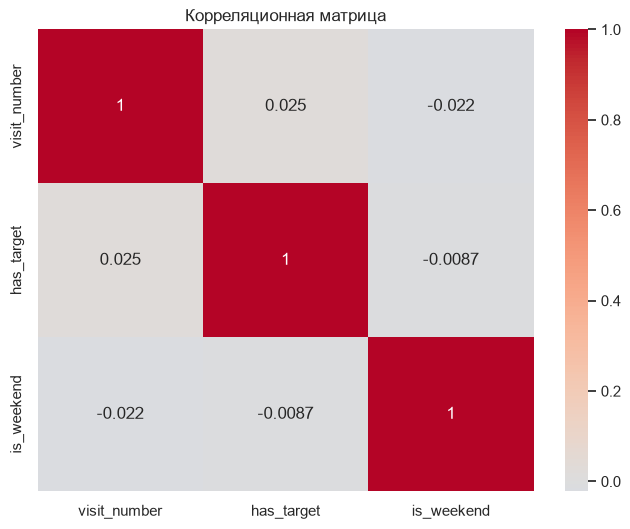

In [19]:
numeric_for_corr = [col for col in numeric_cols if col in ["visit_number", "visit_hour", "visit_dayofweek", "visit_month", "is_weekend", "has_target"]]

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

## Итоговые выводы по EDA

По результатам разведочного анализа можно сделать следующие выводы:

1. В данных присутствуют пропуски, поэтому при моделировании потребуется предобработка.
2. Дубликаты и типы данных были проверены до начала обучения модели.
3. Целевая переменная несбалансирована, поэтому при оценке модели недостаточно использовать только accuracy.
4. Конверсия зависит от источника трафика, устройства, географии и времени визита.
5. Простые инженерные признаки (is_organic, is_paid, is_first_visit, is_social, is_weekend) являются интерпретируемыми и потенциально полезными для модели.
6. Признаки из ga_hits.csv, агрегированные по всей сессии, не используются в модели, так как они приводят к утечке данных.
7. Для дальнейшего моделирования разумно использовать только безопасные признаки визита из ga_sessions.csv и выполнять временное разбиение train/test.